# 00 · Data Overview

Notebook base para entender el dataset, revisar la variable objetivo y dejar preparadas las decisiones de modelado comparables entre enfoques espaciales y no lineales.

## Objetivos

- Revisar calidad y cobertura de datos.
- Inspeccionar la distribución de `precio_m2` o su transformación.
- Explorar patrones espaciales iniciales.
- Detectar variables candidatas y potenciales sesgos del dataset.
- Dejar documentadas hipótesis para los notebooks de modelado.

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "00_data_overview"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
PROJECT_ROOT

PosixPath('/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres')

## Carga de datos

Se cargan los datos procesados de `data/processed`: alquiler (`arg_alquiler_dat_processed.csv`) y venta (`arg_venta_data_processed.csv`). El análisis principal se enfoca en el dataset de venta.

Resumen rápido:
- `arg_alquiler_data_processed.csv`: 989 filas x 31 columnas.
- `arg_venta_data_processed.csv`: 10614 filas x 31 columnas.
- Objetivo base para modelado: `precio_sobre_m2`.
- Coordenadas espaciales: `longitud`, `latitud`.
- Variables con nulos importantes: `tipo_unidad`, `antiguedad`, `estado`, `disposicion`, `orientacion`, `estado_edificio`.


In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "processed"
rental_path = DATA_DIR / "arg_alquiler_data_processed.csv"
sale_path = DATA_DIR / "arg_venta_data_processed.csv"

with pd.option_context("display.max_columns", 200):
    df_rental = pd.read_csv(rental_path)
    df_sale = pd.read_csv(sale_path)

# Dataset principal para análisis de venta.
df = df_sale
df["precio_sobre_m2"] = df["precio"] / df["area_m2_total"]
target_col = "precio_sobre_m2"
coord_cols = ["longitud", "latitud"]
id_col = "id"

print("Dataset de alquileres:", df_rental.shape)
print("Dataset de venta:", df_sale.shape)
print("Columnas comunes entre ambos datasets:")
print(sorted(set(df_rental.columns) & set(df_sale.columns)))

print("Primeras filas del dataset de venta:")
display(df_sale.head(3))


Dataset de alquileres: (3155, 93)
Dataset de venta: (49802, 96)
Columnas comunes entre ambos datasets:
['Nombre', 'ambientes', 'ambientes_scaled', 'antiguedad', 'antiguedad_cat', 'antiguedad_scaled', 'apadrinada', 'area', 'area_m2_cubierta', 'area_m2_descubierta', 'area_m2_descubierta_scaled', 'area_m2_total', 'area_m2_total_scaled', 'area_metro', 'banos', 'banos_scaled', 'barrio_left', 'barrio_right', 'boletin_of', 'clasificac', 'cocheras', 'cocheras_scaled', 'comuna_left', 'comuna_right', 'decreto', 'disposicion', 'disposicion_Contrafrente', 'disposicion_Frente', 'disposicion_Interno', 'disposicion_Lateral', 'dist_areas_programaticas', 'dist_areas_programaticas_scaled', 'dist_avenida_rivadavia', 'dist_avenida_rivadavia_scaled', 'dist_espacio_verde', 'dist_espacio_verde_scaled', 'dist_est_educativo', 'dist_est_educativo_scaled', 'dist_hospital', 'dist_hospital_scaled', 'dist_subte', 'dist_subte_scaled', 'dist_universidad', 'dist_universidad_scaled', 'dormitorios', 'estado', 'estado_ed

,idx,id_left,url,precio,moneda,expensas,tipo_unidad,area_m2_cubierta,area_m2_descubierta,area_m2_total,antiguedad,estado_edificio,ambientes,banos,estado,disposicion,orientacion,latitud,longitud,image_url,imagen_path,valido_desde,valido_hasta,cocheras,dormitorios,informacion_adicional,pozo,id_right,objeto,barrio_left,comuna_left,perimetro_,area_metro,antiguedad_cat,dist_subte,nearest_subte,dist_universidad,nearest_universidad,dist_hospital,nearest_hospital,dist_est_educativo,nearest_est_educativo,id_left.1,nombre_left,nom_mapa,barrio_right,comuna_right,ubicacion,clasificac,tiene_pati,apadrinada,decreto,fecha_decr,ordenanza_,fecha_orde,boletin_of,fecha_bole,area,perimetro,observacio,dist_espacio_verde,id_right.1,nombre_right,dist_areas_programaticas,Nombre,dist_avenida_rivadavia,n_universidades_1000m,n_robos_1000m,n_ventas_1000m_90d,velocidad_ventas_1000m_90d,estado_num,disposicion_Frente,disposicion_Contrafrente,disposicion_Lateral,disposicion_Interno,log_precio,area_m2_total_scaled,area_m2_descubierta_scaled,ambientes_scaled,banos_scaled,cocheras_scaled,antiguedad_scaled,expensas_scaled,dist_subte_scaled,dist_universidad_scaled,dist_hospital_scaled,dist_est_educativo_scaled,dist_espacio_verde_scaled,dist_areas_programaticas_scaled,dist_avenida_rivadavia_scaled,n_robos_1000m_scaled,n_universidades_1000m_scaled,n_ventas_1000m_90d_scaled,velocidad_ventas_1000m_90d_scaled,split,precio_sobre_m2
0,35100,19262707.0,https://www.argenprop.com/departamento-en-vent...,186890.0,USD,0.0,NaN,44.7,0.0,56.0,2.000000,0.0,2.0,1.0,Excelente,Frente,NaN,-34.573410,-58.432940,https://www.argenprop.com/static-content/70726...,NaN,2026-04-11 05:58:49.116648,2026-04-22 04:43:51.823219,0.0,1.0,NaN,0.0,21.0,BARRIO,Palermo,14.0,22830.60,15922586.17,2,273.440042,Ministro Carranza - Miguel Abuelo,163.040250,Instituto de Enseñanza Superior del Ejército,2.218638e+06,Hospital Especializado de Gastroenterologia B....,189302.366912,Establecimiento educativo CARLOS PELLEGRINI,915,Paseo Arzoumanian,Paseo Arzoumanian,Palermo,14,"CHENAUT, AV. E/ CAMPOS, LUIS M., AV. Y CAMPO...",CANTERO CENTRAL,SI,NO,861/009,29/09/2009,LEY 3165,NaN,3274,NaN,2016.322443,666.927284,NaN,112.111502,4,Área Programática Hospital Dr. I. Pirovano,0.0,Avenida Rivadavia,5306.347038,3,175,50,0.555556,5,1,0,0,0,12.138281,0.315929,-0.406381,-0.388097,-0.078613,-0.06482,-1.173362,-0.760239,-0.728709,-0.794863,-0.766055,0.492388,-0.704095,-0.190995,0.637462,-0.396197,-0.103143,0.223203,0.223203,train,3337.321429
1,21664,8977568.0,https://www.argenprop.com/departamento-en-vent...,115000.0,USD,0.0,NaN,37.0,3.0,40.0,17.144872,0.0,2.0,1.0,Excelente,Frente,NaN,-34.640177,-58.518546,https://www.argenprop.com/static-content/86577...,NaN,2026-03-31 06:26:09.081914,2026-04-11 06:01:17.339097,0.0,1.0,NaN,0.0,15.0,BARRIO,Liniers,9.0,9256.93,4374419.15,17,4596.694584,San Pedrito,4564.423701,Universidad de Flores,2.228915e+06,Hospital Especializado de Gastroenterologia B....,180801.904012,Establecimiento educativo CARLOS PELLEGRINI,563,Plaza de Isidora,Pza. de Isidora,Liniers,9,CAAGUAZU ENTRE LARRAZABAL Y FONROUGE,PLAZA,SI,NaN,De Hecho,08/10/2013,LEY N° 4.677,NaN,4271,NaN,2687.984565,552.151180,NaN,574.705597,10,Área Programática Hospital Donacion F. Santoj...,0.0,Avenida Rivadavia,162.716842,0,193,4,0.044444,5,1,0,0,0,11.652696,-0.058954,-0.187167,-0.388097,-0.078613,-0.06482,-0.394064,-0.760239,2.387669,3.285040,1.998297,-1.792244,2.197814,-0.190995,-1.144828,-0.239576,-0.612028,-0.785446,-0.785446,train,2875.000000
2,18181,19225196.0,https://www.argenprop.com/departamento-en-vent...,120000.0,USD,0.0,NaN,32.0,0.0,44.0,11.771134,0.0,2.0,1.0,Excelente,Frente,NaN,-34.550060,-58.469540,https://www.argenprop.com/static-content/69152...,NaN,2026-03-20 21:09:53.672729,2026-04-11 05:57:19.946059,0.0,1.0,NaN,0.0,20.0,BARRIO,Nuñez,13.0,10902.95,4496656.39,12,902.985331,Congreso De Tucuman,1151.286567,Instituto Universitario Naval,2.220539e+06,Hospital Especializado de Gastroenterologia B....,186287.080136,Establecimie

## Visualización 

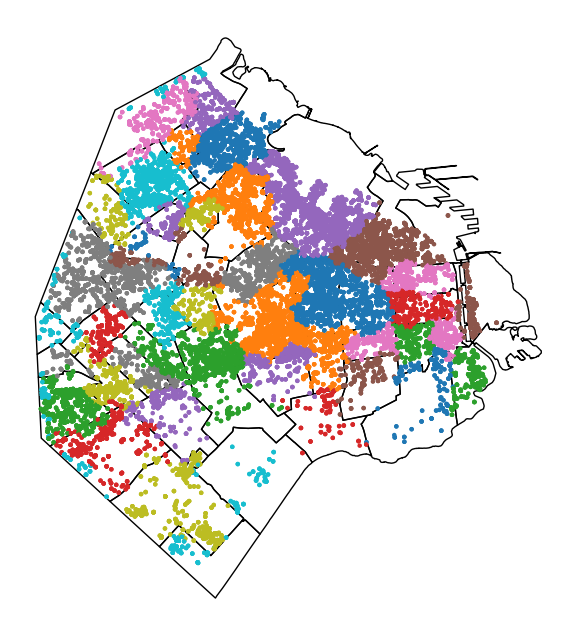

In [5]:

barrios = gpd.read_file(PROJECT_ROOT / "GeoData" / "barrios.geojson")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs='EPSG:4326'
)

barrios = barrios.to_crs(gdf.crs)

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor='black', facecolor='none')
gdf.rename(columns={'barrio_right': 'barrio'}, inplace=True)
gdf.plot(
    ax=ax,
    column='barrio',
    markersize=5,
    legend=False,
)

ax.set_axis_off()
plt.show()


## Cnatidad de publicaciones activas: 

In [6]:
gdf['valido_hasta'].isna().sum()

np.int64(16109)

## Sanity checks iniciales

In [7]:
for name, dataset in [("Alquiler", df_rental), ("Venta", df_sale)]:
    print(f"--- {name} ---")
    print("shape:", dataset.shape)
    print("columnas:", len(dataset.columns))
    print("nulos por columna (%):")
    display((dataset.isna().mean().sort_values(ascending=False) * 100).head(20))
    print("\nTipos de datos:")
    display(dataset.dtypes.sort_index())
    print("\n")

print("Dataset principal para análisis inicial: venta")
print("Columnas objetivo y espaciales:")
print("target_col:", target_col)
print("coord_cols:", coord_cols)
print("id_col:", id_col)

print("Resumen estadístico rápido del dataset de venta:")
display(df.describe(include="all").T.head(20))


--- Alquiler ---
shape: (3155, 93)
columnas: 93
nulos por columna (%):


observacio         100.000000
fecha_orde          99.524564
fecha_bole          99.524564
decreto             65.832013
fecha_decr          64.500792
orientacion         54.453249
apadrinada          46.212361
ordenanza_          45.673534
boletin_of          37.591125
valido_hasta        30.554675
nombre_left         22.408875
nom_mapa            21.901743
tipo_unidad         21.014263
ubicacion            2.757528
imagen_path          0.316957
antiguedad           0.000000
estado_edificio      0.000000
estado               0.000000
area_m2_total        0.000000
banos                0.000000
dtype: float64


Tipos de datos:


Nombre                                   str
ambientes                            float64
ambientes_scaled                     float64
antiguedad                           float64
antiguedad_cat                         int64
                                      ...   
url                                      str
valido_desde                             str
valido_hasta                             str
velocidad_ventas_1000m_90d           float64
velocidad_ventas_1000m_90d_scaled    float64
Length: 93, dtype: object



--- Venta ---
shape: (49802, 96)
columnas: 96
nulos por columna (%):


observacio               100.000000
fecha_bole                99.903618
fecha_orde                99.881531
orientacion               98.132605
tipo_unidad               98.110518
imagen_path               80.398378
informacion_adicional     67.236256
decreto                   65.917031
fecha_decr                64.320710
ordenanza_                50.236938
apadrinada                48.383599
boletin_of                41.693105
valido_hasta              32.346091
nombre_left               25.691739
nom_mapa                  25.123489
ubicacion                  2.971768
image_url                  0.040159
tiene_pati                 0.006024
banos                      0.000000
ambientes                  0.000000
dtype: float64


Tipos de datos:


Nombre                                   str
ambientes                            float64
ambientes_scaled                     float64
antiguedad                           float64
antiguedad_cat                         int64
                                      ...   
url                                      str
valido_desde                             str
valido_hasta                             str
velocidad_ventas_1000m_90d           float64
velocidad_ventas_1000m_90d_scaled    float64
Length: 96, dtype: object



Dataset principal para análisis inicial: venta
Columnas objetivo y espaciales:
target_col: precio_sobre_m2
coord_cols: ['longitud', 'latitud']
id_col: id
Resumen estadístico rápido del dataset de venta:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idx,49802.0,NaN,NaN,NaN,32070.676459,16040.05568,4257.0,17983.25,32147.5,45971.75,59893.0
id_left,49802.0,NaN,NaN,NaN,17774953.157102,2457628.377462,2321489.0,17700916.0,18586796.0,19103984.5,19471604.0
url,49802,17100,https://www.argenprop.com/departamento-en-vent...,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio,49802.0,NaN,NaN,NaN,161365.521083,125153.895638,35000.0,83000.0,125000.0,190000.0,939800.0
moneda,49802,3,USD,49735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expensas,49802.0,NaN,NaN,NaN,121192.545801,159044.466778,0.0,0.0,84000.0,179000.0,1000000.0
tipo_unidad,941,8,Departamento,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2_cubierta,49802.0,NaN,NaN,NaN,57.104738,35.692464,0.0,35.0,49.0,70.0,720.0
area_m2_descubierta,49802.0,NaN,NaN,NaN,5.552408,13.76191,0.0,0.0,0.0,5.0,200.0
area_m2_total,49802.0,NaN,NaN,NaN,42.463874,42.645996,0.0,0.0,39.0,65.0,234.0


In [8]:
df["velocidad_ventas_1000m_90d"]


0        0.555556
1        0.044444
2        0.033333
3        0.855556
4        0.544444
           ...   
49797    1.144444
49798    0.255556
49799    0.000000
49800    0.011111
49801    0.055556
Name: velocidad_ventas_1000m_90d, Length: 49802, dtype: float64

## Variable objetivo

Explorá tanto la escala original como una posible transformación logarítmica si después la vas a usar en todos los modelos.

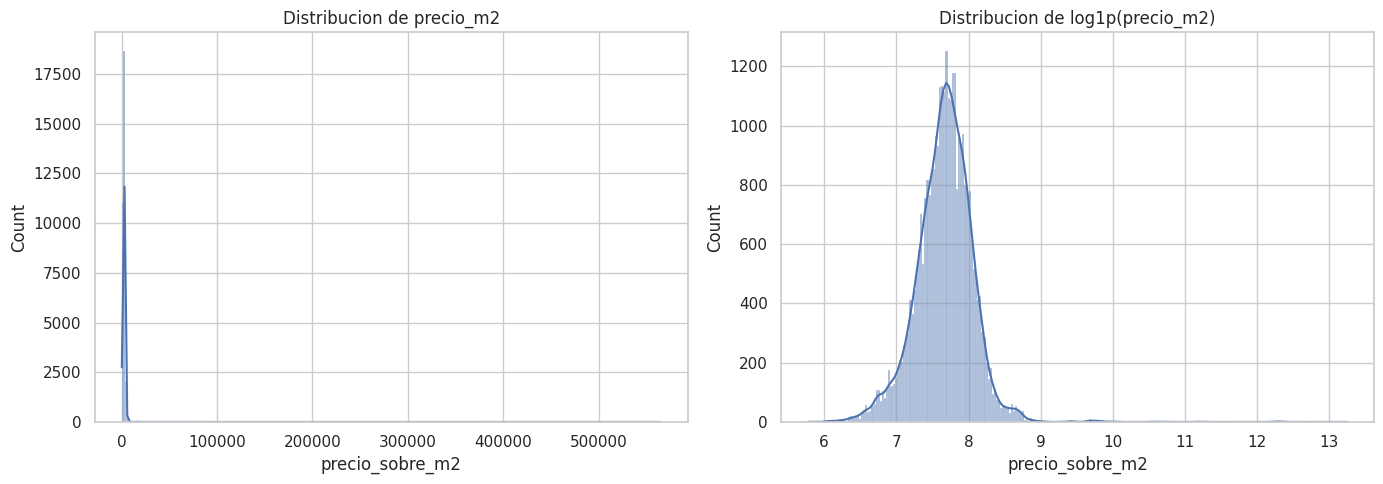

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[target_col], kde=True, ax=axes[0])
axes[0].set_title("Distribucion de precio_m2")
sns.histplot(np.log1p(df[target_col]), kde=True, ax=axes[1])
axes[1].set_title("Distribucion de log1p(precio_m2)")
plt.tight_layout()

## Exploración espacial

Acá conviene mirar mapas simples, densidad por zona y gradientes espaciales del target.

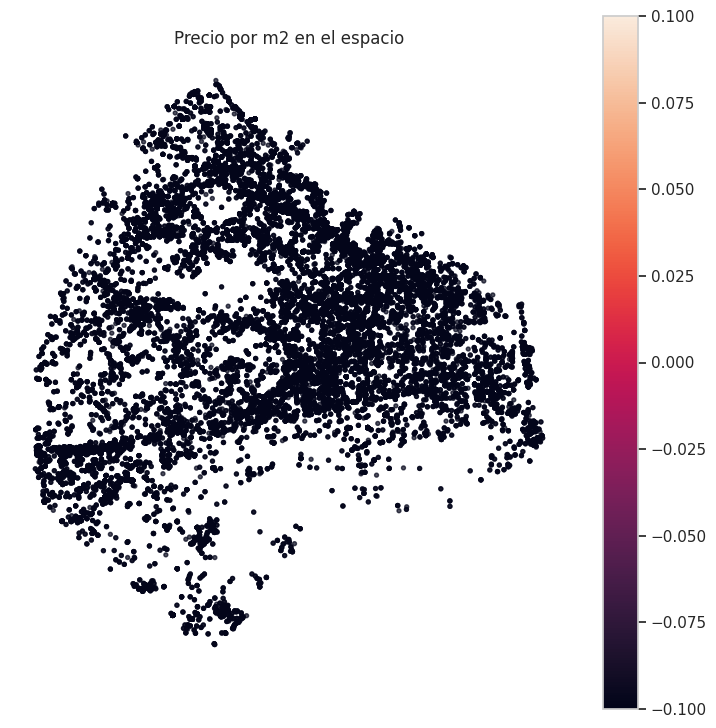

In [10]:
import geopandas as gpd
gdf = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(df[coord_cols[0]], df[coord_cols[1]]), crs="EPSG:4326")
ax = gdf.plot(column=target_col, figsize=(9, 9), alpha=0.7, markersize=8, legend=True)
ax.set_title("Precio por m2 en el espacio")
ax.set_axis_off()

## Correlaciones y señales candidatas

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr(numeric_only=True)[target_col].sort_values(ascending=False)
display(corr.head(20))
display(corr.tail(20))

precio_sobre_m2                      1.000000
cocheras_scaled                      0.156354
cocheras                             0.156354
precio                               0.142423
log_precio                           0.133849
banos_scaled                         0.107733
banos                                0.107733
latitud                              0.074418
area_m2_cubierta                     0.069256
comuna_left                          0.050029
comuna_right                         0.047443
dist_avenida_rivadavia_scaled        0.043170
dist_avenida_rivadavia               0.043170
estado_num                           0.042690
perimetro_                           0.041491
area_metro                           0.037385
velocidad_ventas_1000m_90d           0.018954
velocidad_ventas_1000m_90d_scaled    0.018954
n_ventas_1000m_90d_scaled            0.018954
n_ventas_1000m_90d                   0.018954
Name: precio_sobre_m2, dtype: float64

dist_universidad             -0.014708
dist_universidad_scaled      -0.014708
n_robos_1000m_scaled         -0.015577
n_robos_1000m                -0.015577
dist_espacio_verde_scaled    -0.019538
dist_espacio_verde           -0.019538
area_m2_descubierta_scaled   -0.022298
area_m2_descubierta          -0.022298
dist_hospital                -0.025804
dist_hospital_scaled         -0.025804
dist_subte                   -0.026639
dist_subte_scaled            -0.026639
area_m2_total                -0.031702
area_m2_total_scaled         -0.031702
id_right.1                   -0.048781
antiguedad                   -0.065538
antiguedad_scaled            -0.065538
antiguedad_cat               -0.065605
estado_edificio                    NaN
observacio                         NaN
Name: precio_sobre_m2, dtype: float64

## Analisis de correlación espacial

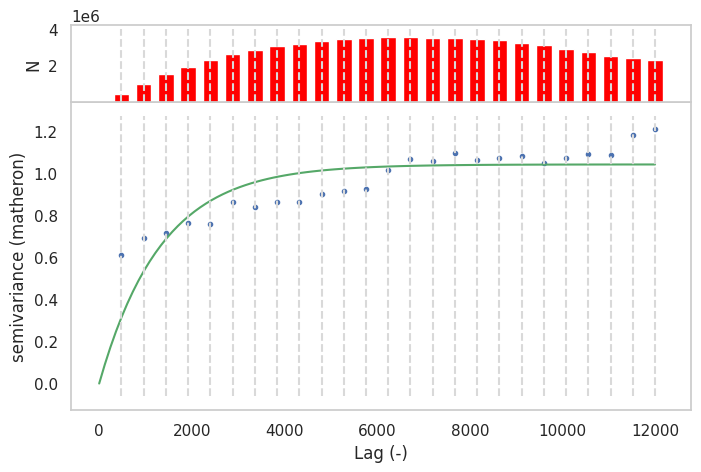

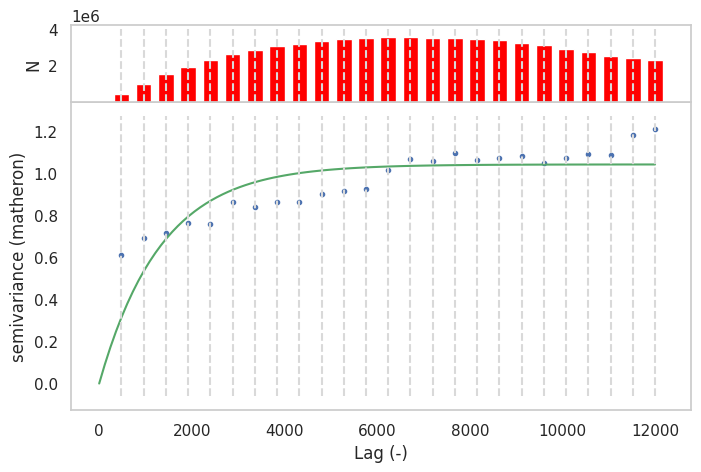

In [14]:
# Reproyeccion a CRS metrico para usar distancias (metros)
from shapely import Point, unary_union
from skgstat import Variogram


gdf_m = (gdf
         .to_crs(epsg=3857)
         .sample(frac=0.4, random_state=42) ) # solo 10% para análisis rápido
barrios_m = gpd.read_file("../GeoData/barrios.geojson").to_crs(gdf_m.crs)
caba_polygon = unary_union(barrios_m.geometry)

xmin, ymin, xmax, ymax = caba_polygon.bounds
grid_size = 300

xs = np.linspace(xmin, xmax, grid_size)
ys = np.linspace(ymin, ymax, grid_size)

xx, yy = np.meshgrid(xs, ys)
coords_grid = np.column_stack([xx.ravel(), yy.ravel()])

gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_grid],
    crs=gdf_m.crs
)

gdf_grid = gdf_grid[gdf_grid.within(caba_polygon)]
coords_grid = np.array([(p.x, p.y) for p in gdf_grid.geometry])

# Target: precio por m2
precio_por_m2 = gdf_m["precio"] / gdf_m["area_m2_total"]

mask = (
    np.isfinite(precio_por_m2) &
    (gdf_m["area_m2_total"] >= 15)
)

# Coordenadas y variable (en metros)
x = gdf_m.geometry.x.values[mask]
y = gdf_m.geometry.y.values[mask]
v = precio_por_m2.values[mask]

coords = np.column_stack([x, y])

# Si hay coords duplicadas exactas, el variograma/kriging pueden fallar.
# Jitter minimo en metros solo para esas filas (reproducible).
np.random.seed(42)
_, uniq_counts = np.unique(coords, axis=0, return_counts=True)
if (uniq_counts > 1).any():
    # identificamos duplicados de forma simple por hashing
    import pandas as _pd
    _dfc = _pd.DataFrame(coords, columns=["x", "y"])
    dup_mask = _dfc.duplicated(subset=["x", "y"], keep=False).to_numpy()
    coords[dup_mask, 0] += np.random.normal(0, 1.0, size=dup_mask.sum())
    coords[dup_mask, 1] += np.random.normal(0, 1.0, size=dup_mask.sum())
    x = coords[:, 0]
    y = coords[:, 1]

V = Variogram(
    coords,
    v,
    model="exponential",
    n_lags=25,
    maxlag=12000
)

range_ = V.parameters[0]
sill = V.parameters[1]
nugget = V.parameters[2]

V.plot()


In [15]:
range_

np.float64(4013.6219335240153)

## Hallazgos e hipótesis

- ¿Qué señales parecen más explicativas?
- ¿Dónde hay heterogeneidad espacial visible?
- ¿Qué outliers conviene tratar antes del modelado?
- ¿Qué variables deberían estar sí o sí en todos los modelos?